**Quantum variance simulation**

This program simulates M identical stocks using the quantum model, and plots some of the variance properties. 

Functions to generate points (z,v) for different periods T.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic, norm, skewnorm


def generate_multi_period_dataset(t_periods_list, n_days=100000, sigma=0.1):
    """
    Loops over a list of period lengths T, runs the simulation for each,
    and returns a single combined DataFrame.
    
    Parameters:
    - t_periods_list (list of int): List of T values to simulate (e.g., 5*[1, 2, 4, 8, 16, 32])
    - n_days (int): Total number of days to divide for each simulation
    - sigma (float): Base standard deviation parameter
    
    Returns:
    - pd.DataFrame: Combined DataFrame containing rows from all simulated periods
    """
    # Use a list to collect DataFrames (much faster than repeatedly appending to a single DataFrame)
    dfs = []
    
    for t in t_periods_list:
        #print(f"Simulating period T = {t}...")
        df_t = simulate_q_periods(n_days=n_days, t_period=t, sigma=sigma)
        dfs.append(df_t)
        
    # Combine all individual DataFrames into a single giant DataFrame
    # ignore_index=True resets the index across the combined rows
    combined_df = pd.concat(dfs, ignore_index=True)
    
    return combined_df

def simulate_q_periods(n_days=100000, t_period=100, sigma=0.1):
    # calculate z, v for periods of length t_period
    num_periods = int(n_days // t_period)
    #vv = 3.5*sigma**4  # variance of variance var(v|z) for any z is 3.5*sigma**4 boost to give higher CV
    
    z_periods = np.zeros(num_periods)
    v_periods = np.zeros(num_periods)
    t_periods = np.full(num_periods, t_period)
    
    for i in range(num_periods):
        state_n = np.random.poisson(lam=0.5)
        sigma_n = sigma * np.sqrt(2 * state_n + 1)
        z_period = np.random.normal(loc=0.0, scale=sigma_n)
        
        expected_variance = sigma**2 + 0.5 * (z_period**2)  # from q-variance
        scale_param = 0.7928
        adjusted_loc = calculate_norm_loc(expected_variance, scale_param)  # using normal for log(v)
        actual_variance = np.exp(norm.rvs(loc=adjusted_loc, scale=scale_param))  # draws value of v
        measured_v = compute_measured_variance(actual_variance, t_period) # note this assumes that z series is normal, it isn't
        
        z_periods[i] = z_period 
        v_periods[i] = measured_v  # actual_variance  # 

    df = pd.DataFrame({
        'z': z_periods,
        'v': v_periods,
        't': t_periods,            # period length
        'i': range(num_periods)    # period number for this length
    })
    
    return df



def compute_measured_variance(actual_variance, t_period):
    """
    Computes a measured sample variance based on a period's true variance 
    and the number of days, assuming normal log returns (lognormal prices).
    
    Parameters:
    actual_variance (float): The expected/true variance over the total period T.
    t_period (int/float): The number of days (data points) in the period.
    
    Returns:
    float: A randomly sampled measured variance for that period.
    """
    # 1. Define degrees of freedom (k)
    # If the daily mean return is estimated from the data, k = n - 1.
    # If returns are strictly demeaned around a known mean of 0, k = t_period.
    degrees_of_freedom = t_period - 1 
    
    # 2. Draw a random sample from the standard Chi-Squared distribution
    chi2_sample = np.random.chisquare(df=degrees_of_freedom)
    
    # 3. Scale the standard sample back into actual variance units
    # Formula: measured_variance = (actual_variance / k) * chi2_sample
    measured_variance = (actual_variance / degrees_of_freedom) * chi2_sample
    
    return measured_variance



target_periods = 5*(np.arange(26)+1)   # does 1 to 26 weeks, can also do [5, 10, 20, 40, 80, 160] or 5*2**np.arange(0, 12) 

# Generate the master dataframe
sigma0SP = 0.137  # use this for comparison with SP500 index
sigma0 = 0.259  # convergence is slower for low sigma0
#sigma0 = sigma0SP
n_days = 5000  #5*int(2**10)  # 2**10=1024  # length for each tick

n_tick = 100  # max 100 for Jupyter
df = []

gamma = 0
scale_param = gamma*sigma0**2 # np.sqrt(3.5)*sigma0**2  # increase this for inter-stock variability
adjusted_loc = calculate_norm_loc(sigma0**2, scale_param) 

actual_variance = np.zeros(n_tick)
for n in range(n_tick):
    actual_variance[n] = np.exp(norm.rvs(loc=adjusted_loc, scale=scale_param))  # draws value of v
    if n == 0:
        actual_variance[n] = sigma0**2
    dfcur = generate_multi_period_dataset(t_periods_list=target_periods, n_days=n_days, sigma=np.sqrt(actual_variance[n]))
    dfcur["tick"] = int(n)
    df.append(dfcur)

df = pd.concat(df, ignore_index=True)
cv0 = np.std(actual_variance)/np.mean(actual_variance)
print(f"{cv0=}")  # CV of min variance is 0.35, for stocks is about 0.53

# Now bin the data
bins = np.arange(-0.625, 0.675, 0.05)
#df['bin_mid'] = pd.cut(df['z'], bins).apply(lambda z: z.mid).astype(float)
df['bin_mid'] = pd.cut(df['z'], bins).apply(lambda z: z.mid if pd.notnull(z) else np.nan).astype(float)
# Note: depending on your pandas version, you can also use:
# df['bin_mid'] = pd.cut(df['z'], bins).array.mid

binned_summary = df.groupby('bin_mid', observed=True)['v'].mean().reset_index()  # columns bin_mid, v

print(df.head(10))
print(df.tail(10))

print(f"\nFinal DataFrame Shape: {df.shape}")
#print(df.sample(5)) # View 5 random rows across different T values


cv0=np.float64(2.0688105138287227e-17)
          z         v  t  i  tick  bin_mid
0  0.513515  0.557794  5  0     0     0.50
1 -0.532357  0.136923  5  1     0    -0.55
2 -0.220412  0.025783  5  2     0    -0.20
3 -1.017378  0.664803  5  3     0      NaN
4 -0.250186  0.178691  5  4     0    -0.25
5  0.005553  0.053477  5  5     0     0.00
6 -0.003962  0.039402  5  6     0     0.00
7  0.149380  0.048660  5  7     0     0.15
8  0.722739  0.037109  5  8     0      NaN
9  0.046331  0.010060  5  9     0     0.05
               z         v    t   i  tick  bin_mid
384390 -0.147185  0.022760  130  28    99    -0.15
384391  0.159975  0.144433  130  29    99     0.15
384392  0.156990  0.114512  130  30    99     0.15
384393  0.185984  0.086749  130  31    99     0.20
384394  0.228854  0.095844  130  32    99     0.25
384395  0.062397  0.018267  130  33    99     0.05
384396  0.475899  0.036788  130  34    99     0.50
384397 -0.179040  0.087015  130  35    99    -0.20
384398 -0.461394  0.131053  1

Now plot the q-variance curve for each stock.

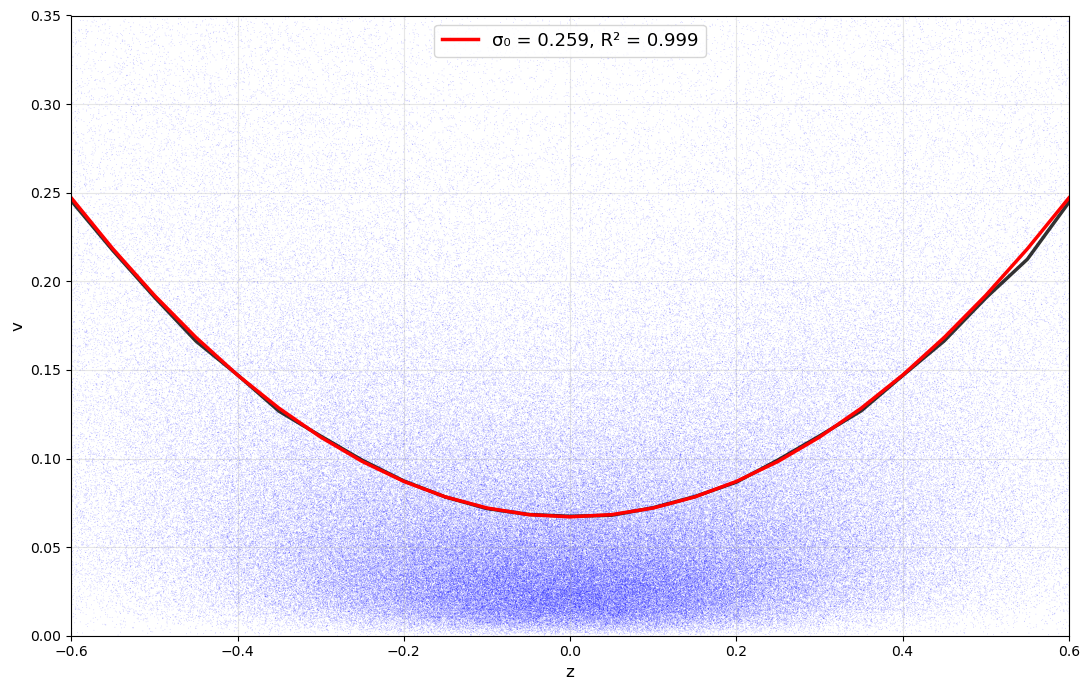

In [25]:
def q_variance_model(z, sigma_0_sq):
    return sigma_0_sq + z**2 / 2


fig, ax = plt.subplots(figsize=(11, 7))  # Slightly widened to make room for the colorbar

# Map the 't' column to the 'c' parameter and choose a colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
#scatter = ax.scatter(df['z'],  df['v'], c=df['t'], cmap='viridis', alpha=0.2, s=1, edgecolors='none')
scatter = ax.scatter(df['z'],  df['v'], color='blue', alpha=0.2, s=0.4, edgecolors='none')

qvarcurve = q_variance_model(binned_summary['bin_mid'], sigma0**2)
ss_res = np.sum((binned_summary['v'] - qvarcurve)**2)
ss_tot = np.sum((binned_summary['v'] - np.mean(binned_summary['v']))**2)
r_squared = 1 - ss_res / ss_tot

# Plot the total binned summary
ax.plot(binned_summary['bin_mid'], binned_summary['v'], color='black', linewidth=2.5, alpha=0.8)

# Plot the q-variance curve
ax.plot(binned_summary['bin_mid'], qvarcurve,
         color='red', lw=2.5,
         label=f'σ₀ = {sigma0:.3f}, R² = {r_squared:.3f}')

# Add a colorbar to act as a legend for the continuous T values
#cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
#cbar.set_label('Period Length (T)', fontsize=12)

# Axis limits and labels
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 0.35)
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('v', fontsize=12)

ax.grid(alpha=0.3)

#plt.title('Quantum model, not from time series', fontsize=14)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()#plt.savefig('Figure_1_N10.png', dpi=300, bbox_inches='tight')

plt.show()

Now plot log variance over all data.

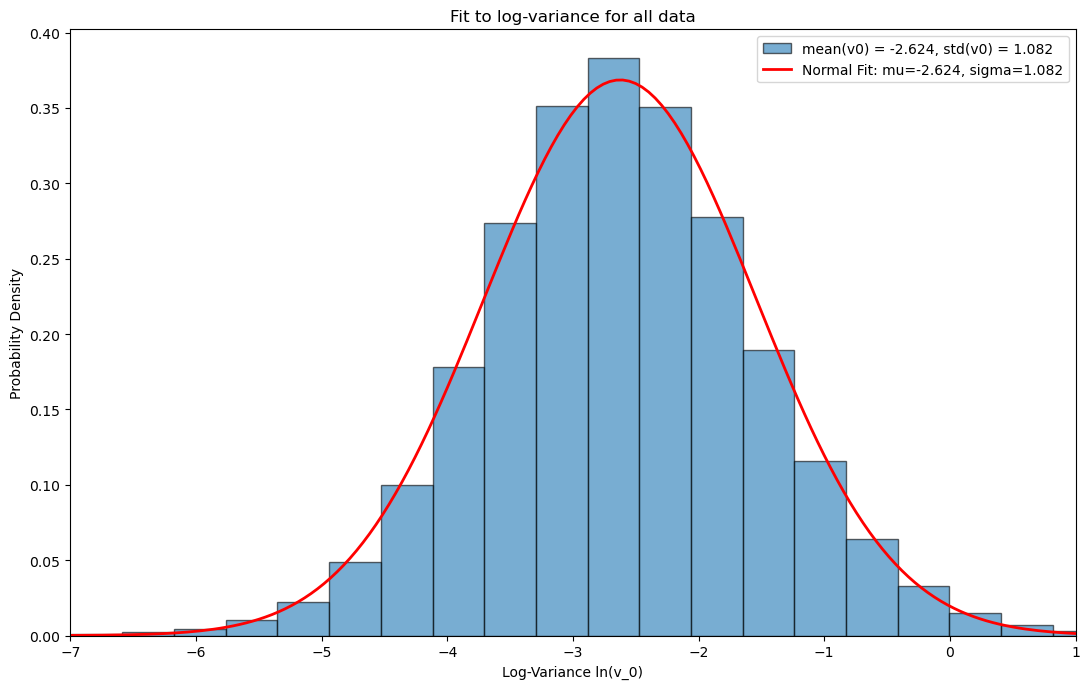

In [26]:
log_v = np.log(df['v'])  # log-transformed values
log_v = log_v[log_v > -7]

# plot the logged data histogram (using density=True for PDF matching)
fig, ax = plt.subplots(figsize=(11, 7))  # Slightly widened to make room for the colorbar
count, bins, ignored = ax.hist(
    log_v, 
    bins=25, 
    edgecolor='black', 
    alpha=0.6, 
    density=True, 
    label=f'mean(v0) = {np.mean(log_v):.3f}, std(v0) = {np.std(log_v):.3f}'
)

# 2. Fit the standard Normal distribution parameters to the log-transformed data
# This returns the empirical mean (mu) and empirical standard deviation (std)
mu_fitted, std_fitted = norm.fit(log_v)

# 3. Create a smooth range of x-values tracking across the log-scale axis
x_arr = np.linspace(min(log_v), max(log_v), 200)

# 4. Calculate the standard Normal PDF values over the log-range
pdf_fitted = norm.pdf(x_arr, loc=mu_fitted, scale=std_fitted)

# Overlay the fitted normal curve line directly
ax.plot(x_arr, pdf_fitted, 'r-', linewidth=2, label=f'Normal Fit: mu={mu_fitted:.3f}, sigma={std_fitted:.3f}')

# Add accurate axis labels, updated titles, and legend
ax.set_xlabel('Log-Variance ln(v_0)')
ax.set_ylabel('Probability Density')
ax.set_title('Fit to log-variance for all data')
ax.legend()
plt.xlim(-7, 1)
plt.tight_layout()
plt.show()

Now plot variance distribution for binned values of z.

Bin (-1.0, -0.9]: Coefficient of Variation = 1.1335, Mean = 0.5288, Std = 0.5994
Bin (-0.9, -0.7]: Coefficient of Variation = 1.2178, Mean = 0.3859, Std = 0.4699
Bin (-0.7, -0.5]: Coefficient of Variation = 1.0969, Mean = 0.2390, Std = 0.2622
Bin (-0.5, -0.3]: Coefficient of Variation = 1.1206, Mean = 0.1427, Std = 0.1599
Bin (-0.3, -0.1]: Coefficient of Variation = 1.1425, Mean = 0.0876, Std = 0.1001
Bin (-0.1, 0.1]: Coefficient of Variation = 1.1290, Mean = 0.0686, Std = 0.0775
Bin (0.1, 0.3]: Coefficient of Variation = 1.1246, Mean = 0.0873, Std = 0.0982
Bin (0.3, 0.5]: Coefficient of Variation = 1.1131, Mean = 0.1431, Std = 0.1592
Bin (0.5, 0.7]: Coefficient of Variation = 1.1422, Mean = 0.2387, Std = 0.2726
Bin (0.7, 0.9]: Coefficient of Variation = 1.0963, Mean = 0.3757, Std = 0.4118


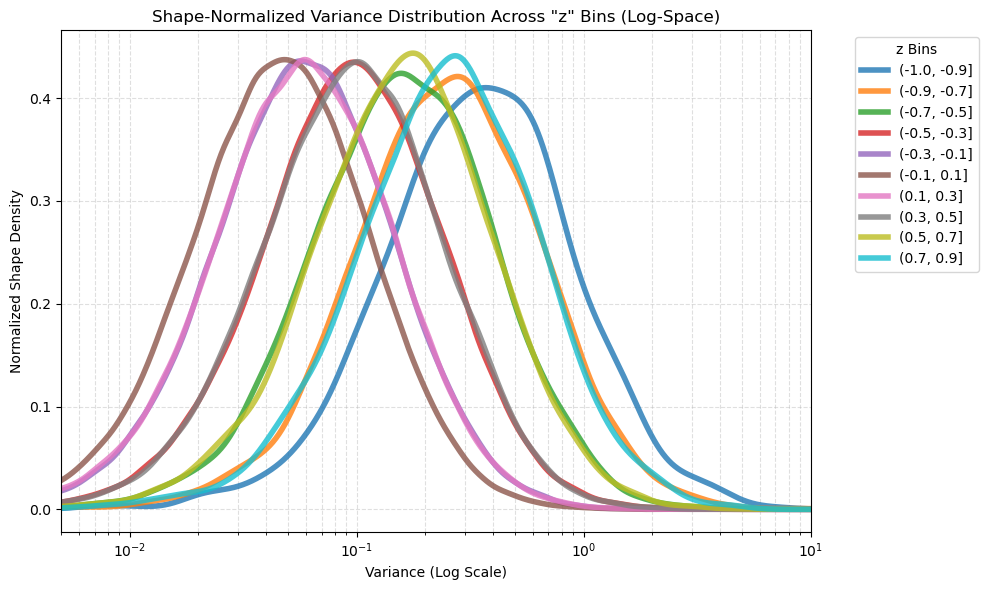

In [27]:
from scipy.stats import gaussian_kde
def analyze_variance_by_bin2(df):
    # 1. Define custom edges to handle z values from -1.0 to 1.0
    bin_edges = [-1.0001] + list(np.arange(-0.9, 1.01, 0.1*2))
    
    # 2. Bin the 'z' column
    df = df.copy()
    df['z_bin'] = pd.cut(df['z'], bins=bin_edges)
    
    # 3. Initialize the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 4. Generate high-resolution log-evaluation grid to match your limits [5e-3, 10]
    # We evaluate directly in natural log space
    x_min, x_max = 5e-3, 10
    log_grid = np.linspace(np.log(x_min), np.log(x_max), num=1000)
    
    # 5. Process each bin sequentially
    for bin_interval, group in df.groupby('z_bin', observed=False):
        # Drop missing values and filter out non-positive values (cannot log 0 or negatives)
        var_data = group['v'].dropna()
        var_data = var_data[var_data > 0]
        
        if var_data.empty:
            continue
            
        # 6. Calculate Coefficient of Variation (CV = SD / Mean) on original data
        mean_val = var_data.mean()
        std_val = var_data.std()
        cv = std_val / mean_val
        print(f"Bin {bin_interval}: Coefficient of Variation = {cv:.4f}, Mean = {mean_val:.4f}, Std = {std_val:.4f}")
            
        # 7. LOG NORMALIZATION: Transform data to log-space to isolate shape 
        log_data = np.log(var_data)
        
        # Build a kernel density estimator in log-space
        # Handling edge cases where a bin might only have 1 distinct value
        try:
            kde = gaussian_kde(log_data)
            density_values = kde(log_grid)
        except np.linalg.LinAlgError:
            continue # Skip bins with zero variance in log-space
        
        # 8. Plot the normalized curves
        # np.exp(log_grid) maps the log evaluation points back to your 5e-3 to 10 scale
        ax.plot(
            np.exp(log_grid), 
            density_values, 
            label=str(bin_interval), 
            alpha=0.8, 
            linewidth=4
        )
    
    # 9. Finalize plot layout and labels
    ax.set_xscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_title('Shape-Normalized Variance Distribution Across "z" Bins (Log-Space)')
    ax.set_xlabel('Variance (Log Scale)')
    ax.set_ylabel('Normalized Shape Density')
    ax.legend(title='z Bins', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()

analyze_variance_by_bin2(df)